# FHR-DQN numbered experiments vs baseline DQN — MountainCar

One config (`configs/config_fhrdqn_2.yaml`), one code path (`FHRDQNAgent`), one
difference per arm: the **baseline arm** strips the FHR term (`fhr_weight: 0.0`, which
reproduces plain `QAgent` training exactly — verified bit-for-bit in
`tests/test_fhrdqn.py`); each **`exp<N>` arm** applies one FHR parameter set from the
config's `experiment.fhr_experiments` block on top of the shared `agent:` block
(unspecified params inherit it). Every arm trains once per seed in
`experiment.seeds`, fanned out as **parallel subprocesses** by
`../../src/run_fhrdqn_seeds.py` (which also defines the Q-network; each child re-seeds
torch/numpy/random via `load_config(CONFIG, seed=s)`, so per-seed groups start
from identical seed state), and every comparison figure reports the seed-average.

MountainCar trains mid-episode (`use_episode_training: False`), so `train_diagnostics.csv`
holds one row per gradient step — the comparison plots aggregate per episode.
The baseline `exp1.ipynb` run showed the greedy-rollout Hankel of Q/V collapsing to
effective rank 1–2 from episode 50 onward (the constant `-1`/step reward makes the
Bellman recurrence roots {1, 1/gamma}), so the low-order AR/ARX penalties target
structure that is genuinely present here.

The low-rank Hankel sweep and the Q-matrix rank tracking
(`analysis.hankel_sweep.enabled: true`, `analysis.methods: q_matrix_dqn`) are ON
by default, so every run records the mechanism diagnostics alongside the reward
curves. To explore further variants, add/edit entries under
`experiment.fhr_experiments` in the config and rerun the launch cell — each entry
becomes its own `exp<N>` arm (the shared baseline and already-finished arms are
reused from the manifest). `analysis.autoregressive_value_probe.enabled: true`
adds held-out AR-fit diagnostics of the frozen greedy policy's value sequences.

All artifacts land under `cached/runs/<name>_<timestamp>/` and are browsable in the
web app: `python result_viewer_app/rank_viewer.py` → the *Training diagnostics* card
shows the TD loss, penalty and coefficient curves per run, and compare mode shows
baseline vs each `exp<N>` as variants.


In [1]:
import csv, sys, pathlib, warnings
import matplotlib.pyplot as plt
import numpy as np
import yaml

# NaN-padded seed stacks legitimately have all-NaN columns (episodes before
# training starts / after early-stopped seeds end) — nanmean warns, we don't care.
warnings.filterwarnings("ignore", message="Mean of empty slice")

EXPS = pathlib.Path.cwd().parents[1] / "src"   # experiments/src — hosts the shared runner
if str(EXPS) not in sys.path:
    sys.path.insert(0, str(EXPS))

from run_fhrdqn_seeds import launch_all, load_runs, CONFIG

## All arms, all seeds — parallel subprocess fan-out

The launch cell reads every numbered experiment under the config's
`experiment.fhr_experiments` and passes them to `launch_all(experiments=EXP_NUMS)`
— without the `experiments` argument the launcher falls back to the legacy
baseline-vs-`fhr` two-arm comparison and **ignores** the numbered experiments.
One training subprocess per (arm, seed): the shared baseline (`fhr_weight: 0.0`
— the single difference, reused from the manifest if already trained) plus one
`exp<N>` arm per config entry. The nets are tiny (~10–20% GPU each), so the
fan-out shares one GPU comfortably. Completed runs are recorded in
`cached/fhrdqn_runs_manifest.json` — re-running the cell only launches missing or
failed pairs (`force=True` reruns the `exp<N>` arms; the shared baseline is only
retrained by CLI `--force` without `--experiment`) — and each child logs to
`cached/logs/fhrdqn_<arm>_seed<N>.log`.

In [2]:
# Train the shared baseline + every numbered experiment defined in the config.
with open(CONFIG) as f:
    EXP_NUMS = sorted(yaml.safe_load(f)["experiment"].get("fhr_experiments") or {})
print(f"experiments in {CONFIG}: {EXP_NUMS}")
manifest = launch_all(max_workers=6, experiments=EXP_NUMS)
SEEDS = manifest["seeds"]
runs_base = load_runs("baseline")
[r["run_dir"] for r in runs_base]

experiments in configs/config_fhrdqn.yaml: [1, 2, 3, 4]
skipping 2 already-completed run(s) recorded in cached/fhrdqn_runs_manifest.json
launching 8 run(s), 6 at a time: [('exp1', 44), ('exp1', 66), ('exp2', 44), ('exp2', 66), ('exp3', 44), ('exp3', 66), ('exp4', 44), ('exp4', 66)]
[exp1 seed 44] done in 56.7 min -> cached/runs/dqn_mountaincar_fhrdqn_2_exp1_seed44_20260814-175812
[exp2 seed 44] done in 58.7 min -> cached/runs/dqn_mountaincar_fhrdqn_2_exp2_seed44_20260814-175812
[exp3 seed 66] done in 59.7 min -> cached/runs/dqn_mountaincar_fhrdqn_2_exp3_seed66_20260814-175812
[exp2 seed 66] done in 63.1 min -> cached/runs/dqn_mountaincar_fhrdqn_2_exp2_seed66_20260814-175812
[exp3 seed 44] done in 65.4 min -> cached/runs/dqn_mountaincar_fhrdqn_2_exp3_seed44_20260814-175812
[exp1 seed 66] done in 70.5 min -> cached/runs/dqn_mountaincar_fhrdqn_2_exp1_seed66_20260814-175812
[exp4 seed 44] done in 31.8 min -> cached/runs/dqn_mountaincar_fhrdqn_2_exp4_seed44_20260814-185455
[exp4 seed 66] do

[PosixPath('/home/souparna/Low-Rank-RL-TL/experiments/classical_control/dqn_mountaincar/cached/runs/dqn_mountaincar_fhrdqn_baseline_seed44_20260813-175543'),
 PosixPath('/home/souparna/Low-Rank-RL-TL/experiments/classical_control/dqn_mountaincar/cached/runs/dqn_mountaincar_fhrdqn_baseline_seed66_20260813-175543')]

## Numbered experiment arms

Loaded from the same manifest. Each arm's FHR parameter set is its
manifest-recorded `agent_overrides` applied on top of the shared `agent:` block —
the `config.yaml` copy inside a run dir does **not** reflect the overrides, so
`agent_by_arm` below is the effective configuration each arm actually trained
with.

In [3]:
ARMS_FHR = [f"exp{n}" for n in EXP_NUMS]
runs_by_arm = {arm: load_runs(arm) for arm in ARMS_FHR}
ALL_ARMS = [("baseline", runs_base)] + [(arm, runs_by_arm[arm]) for arm in ARMS_FHR]

# effective FHR params per arm = shared agent block + the manifest overrides
agent_by_arm = {arm: {**rs[0]["cfg"]["agent"], **(rs[0]["agent_overrides"] or {})}
                for arm, rs in runs_by_arm.items()}
cfg_shared = runs_base[0]["cfg"]   # non-FHR blocks are identical across arms

_PALETTE = ["indianred", "darkorange", "mediumpurple", "seagreen", "goldenrod"]
ARM_COLORS = {"baseline": "steelblue",
              **{arm: _PALETTE[i % len(_PALETTE)] for i, arm in enumerate(ARMS_FHR)}}

def arm_label(arm):
    if arm == "baseline":
        return "baseline (fhr_weight = 0)"
    a = agent_by_arm[arm]
    arx = ", ARX" if a.get("reward_lags") else ""
    return f"{arm} (lambda={a['fhr_weight']}, r={a['fhr_order']}{arx})"

{arm: rs[0]["agent_overrides"] for arm, rs in runs_by_arm.items()}

{'exp1': {'fhr_weight': 0.0191,
  'fhr_order': 4,
  'reward_lags': True,
  'warmup_grad_steps': 750,
  'c_learning_rate': 0.0367},
 'exp2': {'fhr_weight': 0.1,
  'fhr_order': 4,
  'reward_lags': False,
  'rampdown_reward_threshold': None},
 'exp3': {'fhr_weight': 0.5, 'fhr_order': 3, 'reward_lags': False},
 'exp4': {'fhr_weight': 0.5,
  'fhr_order': 3,
  'reward_lags': False,
  'rampdown_reward_threshold': None}}

## Comparison figures

All curves below are seed-averages (thin lines, where shown, are single seeds).
Each figure is shown inline and saved as `figures/comparison_<slug>.png` into
**every** run directory (all arms, all seeds), so any run's page in the result
viewer carries the full comparison.
Diagnostics are one row per gradient step here, so everything is aggregated to
per-episode means before the seed-average.

In [4]:
def read_diagnostics(run_dir):
    """train_diagnostics.csv -> {column: np.array}, aggregated to per-episode
    means (MountainCar logs one row per gradient step)."""
    path = pathlib.Path(run_dir) / "train_diagnostics.csv"
    with open(path) as f:
        rows = list(csv.DictReader(f))
    raw = {k: np.array([float(r[k]) for r in rows]) for k in rows[0]}
    episodes = np.unique(raw["episode"])
    agg = {"episode": episodes}
    for k, v in raw.items():
        if k == "episode":
            continue
        agg[k] = np.array([np.nanmean(v[raw["episode"] == e]) for e in episodes])
    return agg

diags_base = [read_diagnostics(r["run_dir"]) for r in runs_base]
diags_by_arm = {arm: [read_diagnostics(r["run_dir"]) for r in rs]
                for arm, rs in runs_by_arm.items()}
ALL_DIAGS = [("baseline", diags_base)] + [(a, diags_by_arm[a]) for a in ARMS_FHR]

ALL_RUN_DIRS = [r["run_dir"] for _, runs in ALL_ARMS for r in runs]

def save_and_show(fig, slug):
    for d in ALL_RUN_DIRS:
        figdir = pathlib.Path(d) / "figures"
        figdir.mkdir(exist_ok=True)
        fig.savefig(figdir / f"comparison_{slug}.png", dpi=150, bbox_inches="tight")
    plt.show()

def rolling(x, w=50):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

def stack_padded(seqs):
    """(n_seeds, max_len) array, NaN-padded on the right — early-stopped seeds
    are shorter, and the NaN-aware means below only average seeds still running."""
    out = np.full((len(seqs), max(len(s) for s in seqs)), np.nan)
    for i, s in enumerate(seqs):
        out[i, :len(s)] = s
    return out

def seed_mean_rewards(runs):
    """Seed-mean episode-reward curve."""
    return np.nanmean(stack_padded([r["rewards"] for r in runs]), axis=0)

def diag_seed_mean(diags, key):
    """(episode axis, seed-mean curve) for one diagnostics column, aligned on
    the integer episode index and NaN-padded per seed."""
    n_ep = int(max(d["episode"].max() for d in diags)) + 1
    stack = np.full((len(diags), n_ep), np.nan)
    for i, d in enumerate(diags):
        stack[i, d["episode"].astype(int)] = d[key]
    return np.arange(n_ep), np.nanmean(stack, axis=0)

def episode_steps(r):
    """Per-episode env-step counts: the rewards.csv steps column when the run
    has one, else |reward| — exact here: MountainCar pays -1 every step, so |return| is the episode length."""
    if r.get("steps") is not None:
        return np.asarray(r["steps"], dtype=float)
    return np.abs(np.asarray(r["rewards"], dtype=float))

def env_steps_axis(r):
    """Cumulative env steps at the end of each episode — the samples x-axis
    learning curves are reported on in the literature."""
    return np.cumsum(episode_steps(r))

def seed_mean_on_steps(runs, ys, n=400):
    """Seed-average curves whose x values (env steps) don't align across seeds:
    linearly interpolate each seed's (env_steps, y) curve onto a shared grid,
    aggregating only the seeds whose own span covers each grid point — an
    early-stopped seed drops out of the mean instead of being extrapolated.
    ys[i] aligns with the END of runs[i]'s episodes (rolling() output is fine).
    Returns (grid, mean, min, max)."""
    curves = []
    for r, y in zip(runs, ys):
        y = np.asarray(y, dtype=float)
        x = env_steps_axis(r)[-len(y):]
        curves.append((x, y))
    lo = min(float(x[0]) for x, _ in curves)
    hi = max(float(x[-1]) for x, _ in curves)
    grid = np.linspace(lo, hi, n)
    stack = np.full((len(curves), n), np.nan)
    for i, (x, y) in enumerate(curves):
        inside = (grid >= x[0]) & (grid <= x[-1])
        stack[i, inside] = np.interp(grid[inside], x, y)
    return (grid, np.nanmean(stack, axis=0),
            np.nanmin(stack, axis=0), np.nanmax(stack, axis=0))


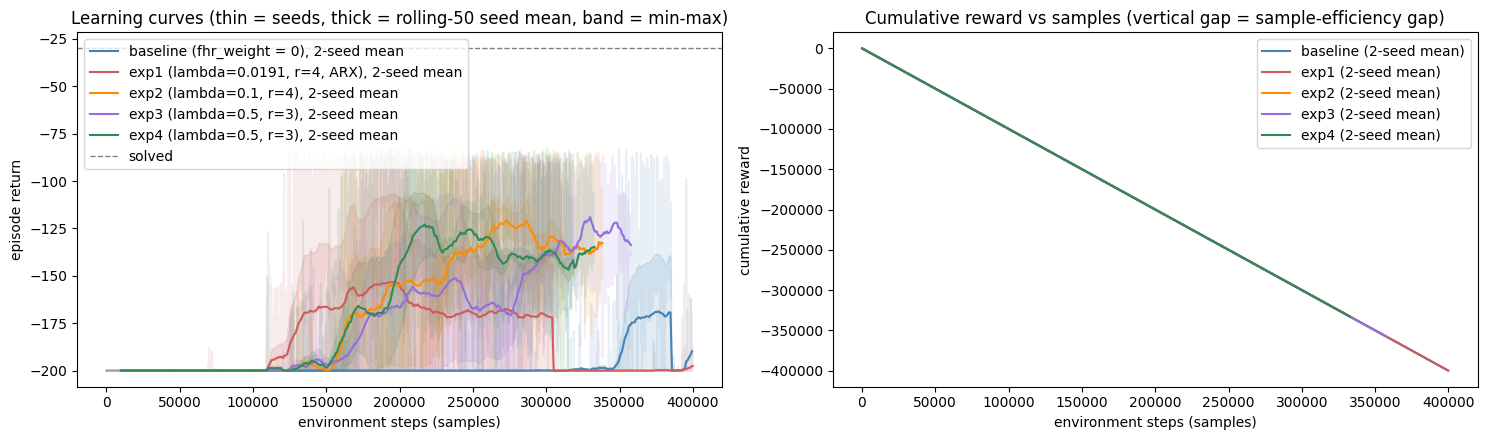

In [5]:
# -- learning curves (x = environment steps, i.e. samples collected) ----------
W = 50
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

ax = axes[0]
for arm, runs in ALL_ARMS:
    for r in runs:
        ax.plot(env_steps_axis(r), r["rewards"], alpha=0.12, color=ARM_COLORS[arm])
for arm, runs in ALL_ARMS:
    grid, m, lo, hi = seed_mean_on_steps(runs, [rolling(r["rewards"], W) for r in runs])
    ax.plot(grid, m, color=ARM_COLORS[arm],
            label=f"{arm_label(arm)}, {len(SEEDS)}-seed mean")
    ax.fill_between(grid, lo, hi, color=ARM_COLORS[arm], alpha=0.15)
ax.axhline(cfg_shared["training"]["solved_reward"], ls="--", c="gray", lw=1, label="solved")
ax.set_xlabel("environment steps (samples)")
ax.set_ylabel("episode return")
ax.set_title(f"Learning curves (thin = seeds, thick = rolling-{W} seed mean, band = min-max)")
ax.legend()

ax = axes[1]
for arm, runs in ALL_ARMS:
    for r in runs:
        ax.plot(env_steps_axis(r), np.cumsum(r["rewards"]), alpha=0.12, color=ARM_COLORS[arm])
    grid, m, lo, hi = seed_mean_on_steps(runs, [np.cumsum(r["rewards"]) for r in runs])
    ax.plot(grid, m, color=ARM_COLORS[arm], label=f"{arm} ({len(SEEDS)}-seed mean)")
    ax.fill_between(grid, lo, hi, color=ARM_COLORS[arm], alpha=0.15)
ax.set_xlabel("environment steps (samples)")
ax.set_ylabel("cumulative reward")
ax.set_title("Cumulative reward vs samples (vertical gap = sample-efficiency gap)")
ax.legend()
fig.tight_layout()
save_and_show(fig, "learning_curves")

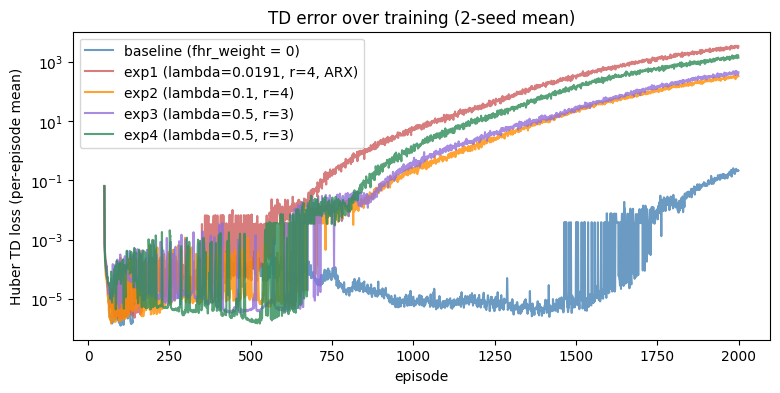

In [6]:
# -- TD error over training --------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
for arm, diags in ALL_DIAGS:
    ax.plot(*diag_seed_mean(diags, "td_loss"), color=ARM_COLORS[arm], alpha=0.8,
            label=arm_label(arm))
ax.set_xlabel("episode"); ax.set_ylabel("Huber TD loss (per-episode mean)")
ax.set_yscale("log")
ax.set_title(f"TD error over training ({len(SEEDS)}-seed mean)")
ax.legend()
save_and_show(fig, "td_error")

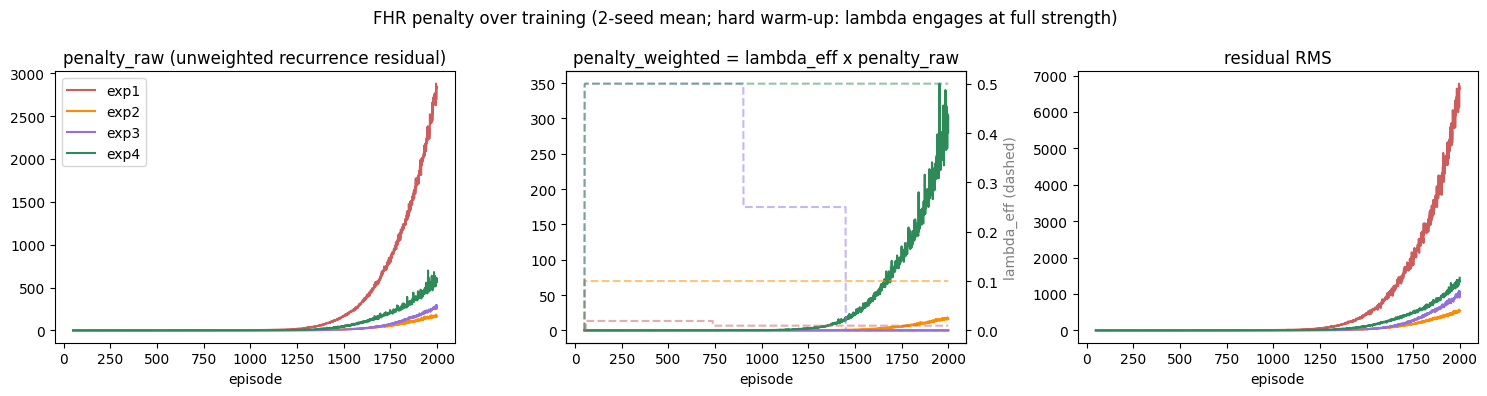

In [7]:
# -- regularisation penalty over training (seed means) -----------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ax2 = axes[1].twinx()
for arm in ARMS_FHR:
    diags, color = diags_by_arm[arm], ARM_COLORS[arm]
    axes[0].plot(*diag_seed_mean(diags, "penalty_raw"), color=color, label=arm)
    axes[1].plot(*diag_seed_mean(diags, "penalty_weighted"), color=color)
    ax2.plot(*diag_seed_mean(diags, "lambda_eff"), color=color, ls="--", alpha=0.5)
    axes[2].plot(*diag_seed_mean(diags, "residual_rms"), color=color)
axes[0].set_title("penalty_raw (unweighted recurrence residual)")
axes[0].legend()
axes[1].set_title("penalty_weighted = lambda_eff x penalty_raw")
ax2.set_ylabel("lambda_eff (dashed)", color="gray")
axes[2].set_title("residual RMS")
for ax in axes:
    ax.set_xlabel("episode")
fig.suptitle(f"FHR penalty over training ({len(SEEDS)}-seed mean; hard warm-up: lambda engages at full strength)")
fig.tight_layout()
save_and_show(fig, "penalty")

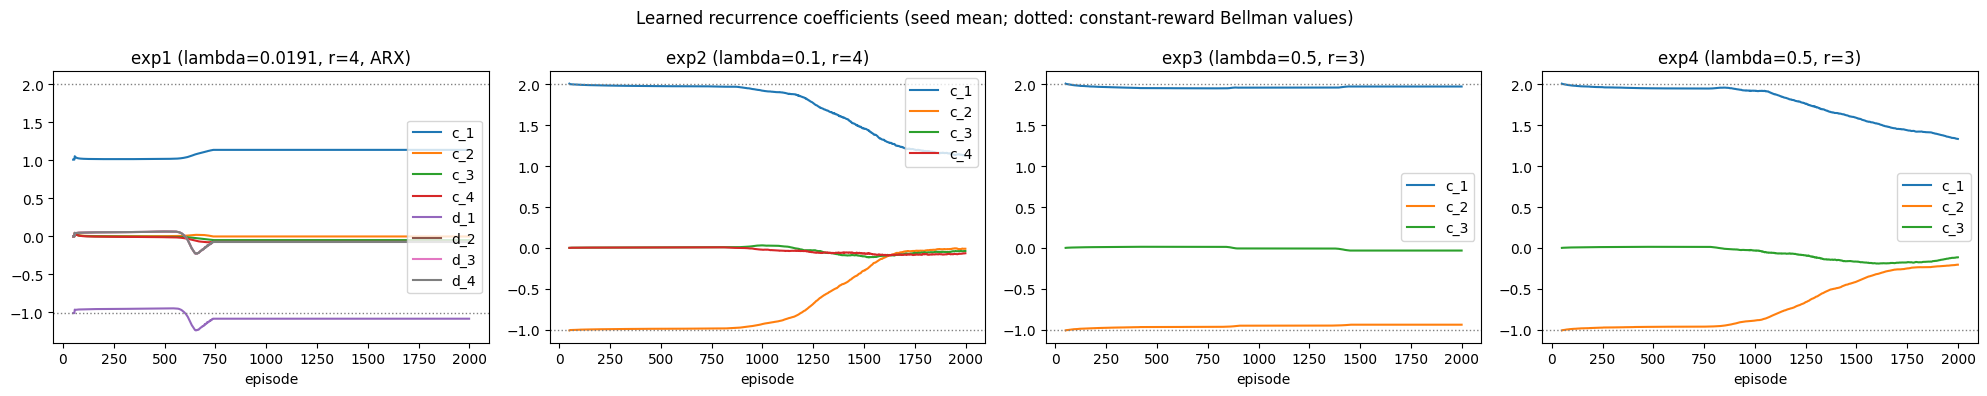

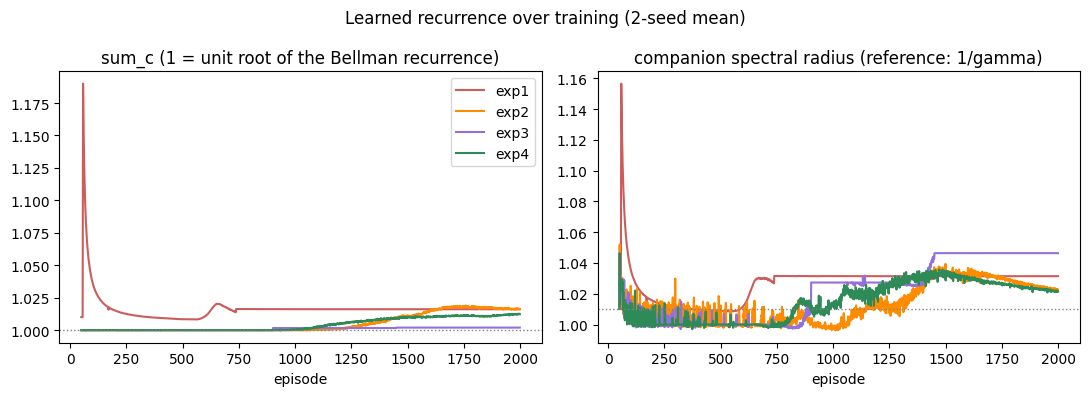

In [8]:
# -- learned recurrence coefficients (one panel per experiment arm) -----------
gamma = cfg_shared["agent"]["discount_factor"]
c_d_cols = {}   # per-arm coefficient columns, reused by the summary cell
fig, axes = plt.subplots(1, len(ARMS_FHR), figsize=(5 * len(ARMS_FHR), 4),
                         squeeze=False)
for ax, arm in zip(axes[0], ARMS_FHR):
    diags, order = diags_by_arm[arm], agent_by_arm[arm]["fhr_order"]
    c_cols = [f"c_{j}" for j in range(1, order + 1) if f"c_{j}" in diags[0]]
    d_cols = [f"d_{j}" for j in range(1, order + 1) if f"d_{j}" in diags[0]]
    c_d_cols[arm] = c_cols + d_cols
    for col in c_cols + d_cols:
        ax.plot(*diag_seed_mean(diags, col), label=col)
    ax.axhline(1 + 1 / gamma, ls=":", c="gray", lw=1)
    ax.axhline(-1 / gamma, ls=":", c="gray", lw=1)
    ax.set_title(arm_label(arm))
    ax.set_xlabel("episode")
    ax.legend()
fig.suptitle("Learned recurrence coefficients (seed mean; dotted: constant-reward Bellman values)")
fig.tight_layout()
save_and_show(fig, "coefficients")

# -- recurrence health: unit root + companion spectral radius -----------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for arm in ARMS_FHR:
    axes[0].plot(*diag_seed_mean(diags_by_arm[arm], "sum_c"),
                 color=ARM_COLORS[arm], label=arm)
    axes[1].plot(*diag_seed_mean(diags_by_arm[arm], "companion_radius"),
                 color=ARM_COLORS[arm])
axes[0].axhline(1.0, ls=":", c="gray", lw=1)
axes[0].set_title("sum_c (1 = unit root of the Bellman recurrence)")
axes[0].legend()
axes[1].axhline(1 / gamma, ls=":", c="gray", lw=1)
axes[1].set_title("companion spectral radius (reference: 1/gamma)")
for ax in axes:
    ax.set_xlabel("episode")
fig.suptitle(f"Learned recurrence over training ({len(SEEDS)}-seed mean)")
fig.tight_layout()
save_and_show(fig, "recurrence_health")

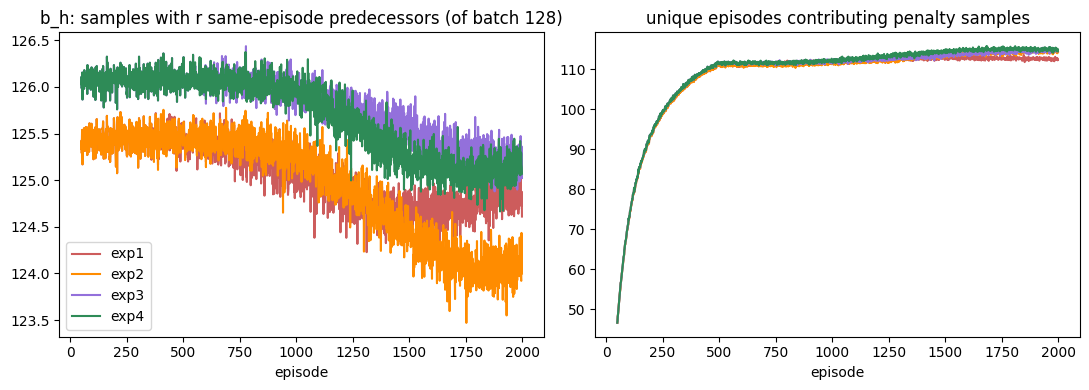

In [9]:
# -- penalty batch composition (seed means) ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for arm in ARMS_FHR:
    axes[0].plot(*diag_seed_mean(diags_by_arm[arm], "b_h"),
                 color=ARM_COLORS[arm], label=arm)
    axes[1].plot(*diag_seed_mean(diags_by_arm[arm], "unique_eps"),
                 color=ARM_COLORS[arm])
axes[0].set_title("b_h: samples with r same-episode predecessors (of batch %d)"
                  % cfg_shared["agent"]["batch_size"])
axes[0].legend()
axes[1].set_title("unique episodes contributing penalty samples")
for ax in axes:
    ax.set_xlabel("episode")
fig.tight_layout()
save_and_show(fig, "penalty_batch")

In [10]:
# -- summary -----------------------------------------------------------------
def solve_episode(rewards, solved, patience=50):
    roll = rolling(rewards, patience)
    idx = np.argmax(roll > solved)
    return int(idx + patience) if roll.max() > solved else None

solved = cfg_shared["training"]["solved_reward"]
for arm, runs in ALL_ARMS:
    bests = [rolling(r["rewards"]).max() for r in runs]
    solves = [solve_episode(r["rewards"], solved) for r in runs]
    # env steps consumed up to the solve episode — the sample-complexity number
    samples = [int(env_steps_axis(r)[s - 1]) if s is not None else None
               for r, s in zip(runs, solves)]
    solved_eps = [s for s in solves if s is not None]
    solved_smp = [s for s in samples if s is not None]
    mean_solve = f"{np.mean(solved_eps):.0f}" if solved_eps else "n/a"
    mean_smp = f"{np.mean(solved_smp):,.0f}" if solved_smp else "n/a"
    print(f"{arm_label(arm)}: mean best rolling-50 {np.mean(bests):.1f} | "
          f"solved {len(solved_eps)}/{len(runs)} seeds | mean solve episode {mean_solve} "
          f"| mean env steps to solve {mean_smp}")
    for r, b, s, smp in zip(runs, bests, solves, samples):
        total = int(env_steps_axis(r)[-1])
        print(f"    seed {r['seed']}: {len(r['rewards'])} episodes / {total:,} env steps, "
              f"best rolling-50 {b:.1f}, solved at episode {s}"
              + (f" ({smp:,} env steps)" if smp is not None else ""))

for arm in ARMS_FHR:
    final = {c: np.mean([d[c][-1] for d in diags_by_arm[arm]])
             for c in c_d_cols[arm] + ["sum_c", "companion_radius"]}
    print(f"{arm} final coefficients (seed mean): "
          + ", ".join(f"{c}={final[c]:.4f}" for c in c_d_cols[arm])
          + f" | sum_c={final['sum_c']:.4f}"
          + f" | companion radius={final['companion_radius']:.4f} (1/gamma={1/gamma:.4f})")
print("nan_skips: " + " | ".join(
    arm + " " + ", ".join(f"{d['nan_skips'][-1]:.0f}" for d in diags)
    for arm, diags in ALL_DIAGS))

baseline (fhr_weight = 0): mean best rolling-50 -163.5 | solved 0/2 seeds | mean solve episode n/a | mean env steps to solve n/a
    seed 44: 2000 episodes / 399,383 env steps, best rolling-50 -189.7, solved at episode None
    seed 66: 2000 episodes / 385,148 env steps, best rolling-50 -137.3, solved at episode None
exp1 (lambda=0.0191, r=4, ARX): mean best rolling-50 -151.9 | solved 0/2 seeds | mean solve episode n/a | mean env steps to solve n/a
    seed 44: 2000 episodes / 304,333 env steps, best rolling-50 -106.2, solved at episode None
    seed 66: 2000 episodes / 399,865 env steps, best rolling-50 -197.6, solved at episode None
exp2 (lambda=0.1, r=4): mean best rolling-50 -107.8 | solved 0/2 seeds | mean solve episode n/a | mean env steps to solve n/a
    seed 44: 2000 episodes / 312,473 env steps, best rolling-50 -106.5, solved at episode None
    seed 66: 2000 episodes / 338,307 env steps, best rolling-50 -109.1, solved at episode None
exp3 (lambda=0.5, r=3): mean best rolling

## Mechanism: low-rank structure over training (seed-averaged)

Every run records the greedy-rollout Hankel sweep (`hankel_sweep.csv`) and the
state-grid Q-matrix rank (`rank_stats.csv`) every `analysis.ep_freq` episodes —
these curves are the mechanism claim: does the FHR penalty pull the
value-sequence Hankel toward the target rank faster than the baseline?
Per-episode spectra figures live in each run's `figures/` (browsable in the
result viewer).

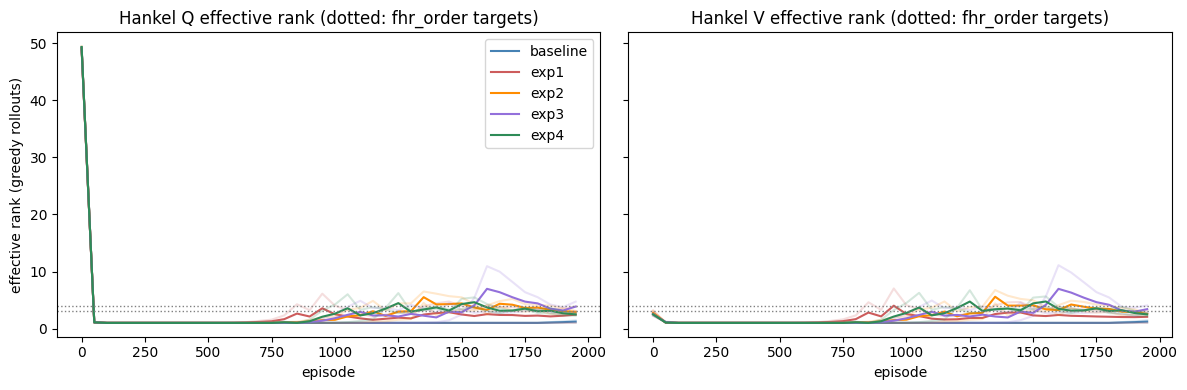

In [11]:
# -- Hankel effective rank over training (thin = seeds, thick = mean) ---------
def rank_rows(run_dir, csv_name, matrix, col="eff_rank"):
    """{episode: mean of `col` over rollouts} for one run."""
    with open(pathlib.Path(run_dir) / csv_name) as f:
        rows = [r for r in csv.DictReader(f) if r["matrix"] == matrix]
    eps = sorted({int(r["episode"]) for r in rows})
    return {e: np.mean([float(r[col]) for r in rows if int(r["episode"]) == e])
            for e in eps}

def arm_rank_stack(runs, csv_name, matrix, col="eff_rank"):
    """(episode axis, (n_seeds, n_ticks) NaN-padded stack) across an arm."""
    per = [rank_rows(r["run_dir"], csv_name, matrix, col) for r in runs]
    all_eps = sorted(set().union(*per))
    stack = np.array([[p.get(e, np.nan) for e in all_eps] for p in per], float)
    return np.array(all_eps), stack

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, matrix in zip(axes, ("Hankel Q", "Hankel V")):
    for arm, runs in ALL_ARMS:
        eps, stack = arm_rank_stack(runs, "hankel_sweep.csv", matrix)
        for row in stack:
            ax.plot(eps, row, color=ARM_COLORS[arm], alpha=0.2)
        ax.plot(eps, np.nanmean(stack, axis=0), color=ARM_COLORS[arm], label=arm)
    for order in sorted({agent_by_arm[a]["fhr_order"] for a in ARMS_FHR}):
        ax.axhline(order, ls=":", c="gray", lw=1)
    ax.set_title(f"{matrix} effective rank (dotted: fhr_order targets)")
    ax.set_xlabel("episode")
axes[0].set_ylabel("effective rank (greedy rollouts)")
axes[0].legend()
fig.tight_layout()
save_and_show(fig, "hankel_rank_evolution")

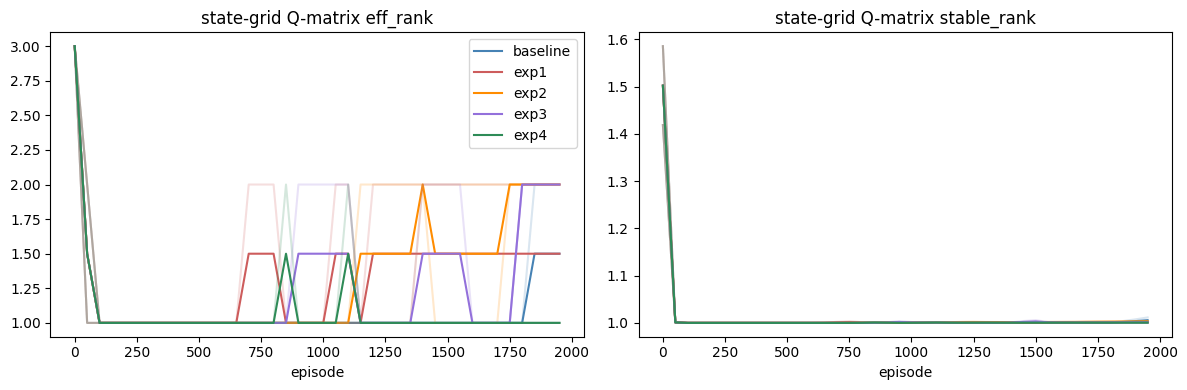

In [12]:
# -- state-grid Q-matrix rank over training ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ("eff_rank", "stable_rank")):
    for arm, runs in ALL_ARMS:
        eps, stack = arm_rank_stack(runs, "rank_stats.csv", "Q-function", col)
        for row in stack:
            ax.plot(eps, row, color=ARM_COLORS[arm], alpha=0.2)
        ax.plot(eps, np.nanmean(stack, axis=0), color=ARM_COLORS[arm], label=arm)
    ax.set_title(f"state-grid Q-matrix {col}")
    ax.set_xlabel("episode")
axes[0].legend()
fig.tight_layout()
save_and_show(fig, "q_matrix_rank")

## Final greedy policies (video)

One greedy episode per (arm, seed), rolled out from `checkpoints/final.pt`
through the exact training-time observation wrappers and reset with the run's
own seed; saved to `<run_dir>/videos/` and embedded below.

In [13]:
from IPython.display import Video, display
from run_fhrdqn_seeds import record_final_videos

for arm in ["baseline"] + ARMS_FHR:
    for seed, path in record_final_videos(arm):
        print(f"{arm} — seed {seed}: {path.name}")
        display(Video(str(path), embed=True, width=420))

/home/souparna/Low-Rank-RL-TL/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/souparna/Low-Rank-RL-TL/experiments/classical_control/dqn_mountaincar/cached/runs/dqn_mountaincar_fhrdqn_baseline_seed44_20260813-175543/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/home/souparna/Low-Rank-RL-TL/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/souparna/Low-Rank-RL-TL/experiments/classical_control/dqn_mountaincar/cached/runs/dqn_mountaincar_fhrdqn_baseline_seed66_20260813-175543/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


baseline — seed 44: epfinal-episode-0.mp4


baseline — seed 66: epfinal-episode-0.mp4


exp1 — seed 44: epfinal-episode-0.mp4


exp1 — seed 66: epfinal-episode-0.mp4


...

exp2 — seed 66: epfinal-episode-0.mp4


exp3 — seed 44: epfinal-episode-0.mp4


exp3 — seed 66: epfinal-episode-0.mp4


exp4 — seed 44: epfinal-episode-0.mp4


exp4 — seed 66: epfinal-episode-0.mp4


## Penalised-window Hankel rank (in-training probe)

Rank measured **where the penalty is applied** — on sampled replay windows
(anchor + `window_rank_lags` same-episode predecessors, online critic(s),
buffer actions) rather than on greedy on-policy rollouts. The probe runs for
every arm **including the λ=0 baseline**, which samples and measures the same
windows, so its curve is the control: if FHR operates as a rank constraint,
its arms should push the window rank / the penalty-block tail ratio *below*
the baseline on exactly these windows. Only instrumented runs
(`agent.window_rank_every > 0`, e.g. the `*_wrank` config family) carry
`window_hankel.csv`; older runs are skipped. Raw window matrices are in each
run's `window_matrices/` for offline re-analysis.


In [ ]:
# Penalised-window Hankel rank: scans every manifest under cached/ for runs
# carrying window_hankel.csv (the in-training probe's output) and, per
# family, plots rank + penalty-block tail ratio vs env steps for every arm.
import pathlib, sys
_repo = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "analysis").is_dir())
if str(_repo / "src") not in sys.path:
    sys.path.insert(0, str(_repo / "src"))
import numpy as np
import matplotlib.pyplot as plt
from analysis.low_rank.window_rank import (arm_tick_metrics,
                                           discover_probe_runs,
                                           final_quarter_summary)

_families = discover_probe_runs("cached")
if not _families:
    print("no instrumented runs under cached/ — launch a family with "
          "agent.window_rank_every > 0 (see the *_wrank config) first")
_palette = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
            "tab:cyan", "peru", "orchid", "tab:olive", "crimson"]
for _mname, _arms in _families.items():
    _fig, (_ax_r, _ax_p) = plt.subplots(1, 2, figsize=(13, 4.4))
    print(f"===== {_mname} =====")
    print(f"{'arm':24s} {'rank@99.9%':>10} {'rank@99%':>9} {'s2/s1':>8} "
          f"{'pen tail':>9}   (final-quarter means, seeds x critics)")
    _ci = 0
    for _arm, _dirs in _arms.items():
        _mets = arm_tick_metrics(_dirs)
        if not _mets:
            continue
        if _arm == "baseline":
            _col = "black"
        else:
            _col = _palette[_ci % len(_palette)]
            _ci += 1
        for _k, (_seed, _m) in enumerate(_mets):
            _lab = _arm if _k == 0 else None
            _lw = 2.0 if _arm == "baseline" else 1.2
            _ax_r.plot(_m["env_steps"], _m["rank999"], color=_col,
                       alpha=0.85, lw=_lw, label=_lab)
            _ax_p.semilogy(_m["env_steps"], _m["pen_tail_ratio"], color=_col,
                           alpha=0.85, lw=_lw, label=_lab)
        _s = final_quarter_summary(_mets)
        if _s:
            print(f"{_arm:24s} {_s['rank999']:10.1f} {_s['rank99']:9.1f} "
                  f"{_s['s2_s1']:8.4f} {_s['pen_tail_ratio']:9.4f}")
    _ax_r.set(title="energy rank @ 99.9% — penalised replay windows",
              xlabel="env steps", ylabel="rank")
    _ax_p.set(title="penalty-block tail  sigma_{r+1} / sigma_1",
              xlabel="env steps")
    for _ax in (_ax_r, _ax_p):
        _ax.legend(fontsize=7.5)
    _fig.suptitle(_mname, fontsize=10)
    plt.tight_layout()
    plt.show()
